In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from scipy.stats import ttest_ind
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Outlier Detection

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

FOLDERS = {
    "data/full-drumstick/0": "No fracture",
    "data/full-drumstick/25": "25% Fracture",
    "data/full-drumstick/50": "50% Fracture",
    "data/full-drumstick/75": "75% Fracture",
    "data/full-drumstick/100": "100% Fracture"
}

group_data = {}

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    if not csv_files:
        print(f"No CSV files found in {folder}")
        continue

    impedances = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        # Skip incomplete sweeps
        if len(df) != len(frequency):
            print(
                f"Skipping {csv_file.name}: "
                f"{len(df)} rows instead of {len(frequency)}"
            )
            continue

        impedances.append(df["impedance"].values)

    if len(impedances) == 0:
        print(f"No valid files found in {folder}")
        continue

    impedances = np.vstack(impedances)

    group_data[label] = {
        "frequency": frequency,
        "mean": np.mean(impedances, axis=0),
        "std": np.std(impedances, axis=0),
        "raw": impedances,
        "n": len(csv_files)
    }

    print(f"{label}: {len(impedances)} files loaded")

No CSV files found in data/full-drumstick/0
No CSV files found in data/full-drumstick/25
No CSV files found in data/full-drumstick/50
No CSV files found in data/full-drumstick/75
No CSV files found in data/full-drumstick/100


In [3]:
print("OUTLIER REPORT")
print("=" * 40)

for group_name, data in group_data.items():

    sweep_means = np.mean(
        data["raw"],
        axis=1
    )

    z_scores = np.abs(
        zscore(sweep_means)
    )

    outliers = np.where(
        z_scores > 2.5
    )[0]

    print(f"\n{group_name}")

    if len(outliers) == 0:
        print("No outliers found")

    else:
        print(f"Outliers: {outliers}")

OUTLIER REPORT


Mean and Standard deviation

In [4]:
plt.style.use('default')

C:\Users\daank\AppData\Local\Temp\ipykernel_13900\1670230022.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


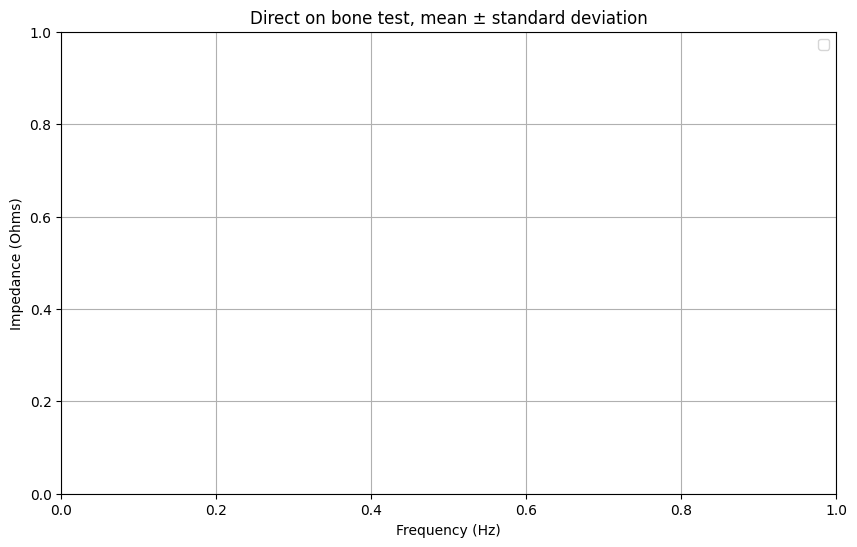

In [5]:
plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():
    plt.plot(
        data["frequency"],
        data["mean"],
        linewidth=2,
        label=f"{group_name} (n={data['n']})"
    )

    plt.fill_between(
        data["frequency"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance (Ohms)")
plt.title("Direct on bone test, mean ± standard deviation")
plt.legend()
plt.grid()

plt.savefig("on_skin_cuts_01_mean_sd.png", dpi=300)
plt.show()

C:\Users\daank\AppData\Local\Temp\ipykernel_13900\1465685388.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


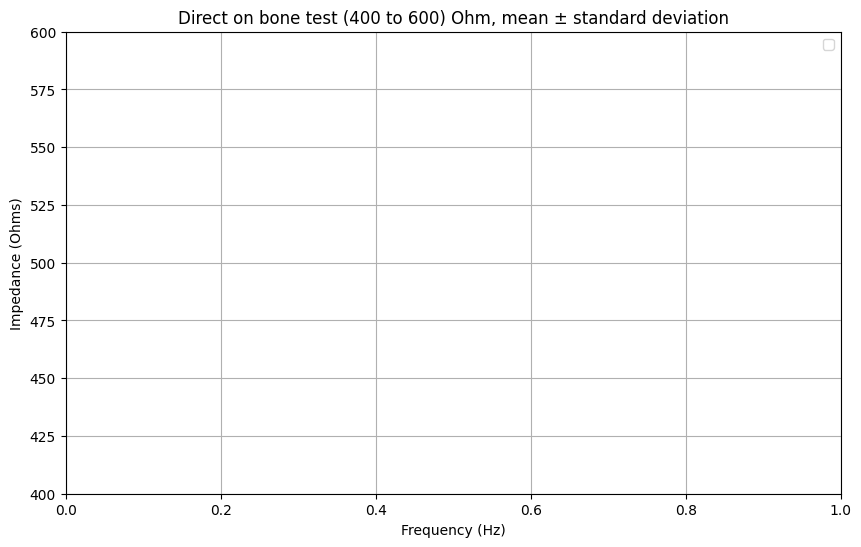

In [6]:
plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():
    plt.plot(
        data["frequency"],
        data["mean"],
        linewidth=2,
        label=f"{group_name} (n={data['n']})"
    )

    plt.fill_between(
        data["frequency"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance (Ohms)")
plt.title("Direct on bone test (400 to 600) Ohm, mean ± standard deviation")
plt.legend()
plt.grid()

plt.ylim(400, 600)

plt.savefig("on_skin_cuts_limited_mean_sd.png", dpi=300)
plt.show()

print the mean and standard deviation at 1000 Hz for each group

In [7]:
for group_name, data in group_data.items():

    mean_value = np.mean(data["mean"])
    std_value = np.std(data["mean"])

    print(f"{group_name}")
    print(f"Mean: {mean_value:.2f} Ω")
    print(f"Std : {std_value:.2f} Ω")
    print()

Smoothed Curves

C:\Users\daank\AppData\Local\Temp\ipykernel_13900\1985844820.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


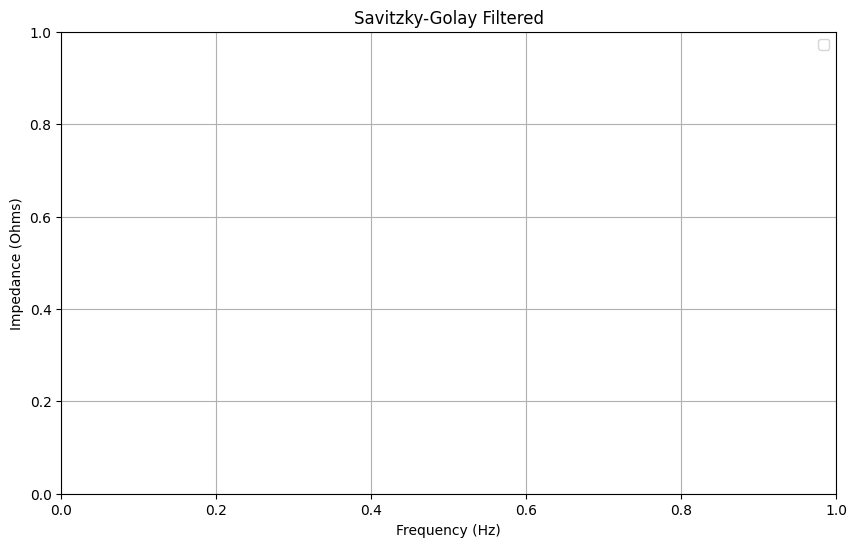

In [8]:
plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():
    filtered = savgol_filter(
        data["mean"],
        window_length=7,
        polyorder=2
    )

    plt.plot(
        data["frequency"],
        filtered,
        linewidth=2,
        label=group_name
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance (Ohms)")
plt.title("Savitzky-Golay Filtered")
plt.legend()
plt.grid()

plt.savefig("02_smoothed.png", dpi=300)
plt.show()

Coefficient of Variation

C:\Users\daank\AppData\Local\Temp\ipykernel_13900\2763668891.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


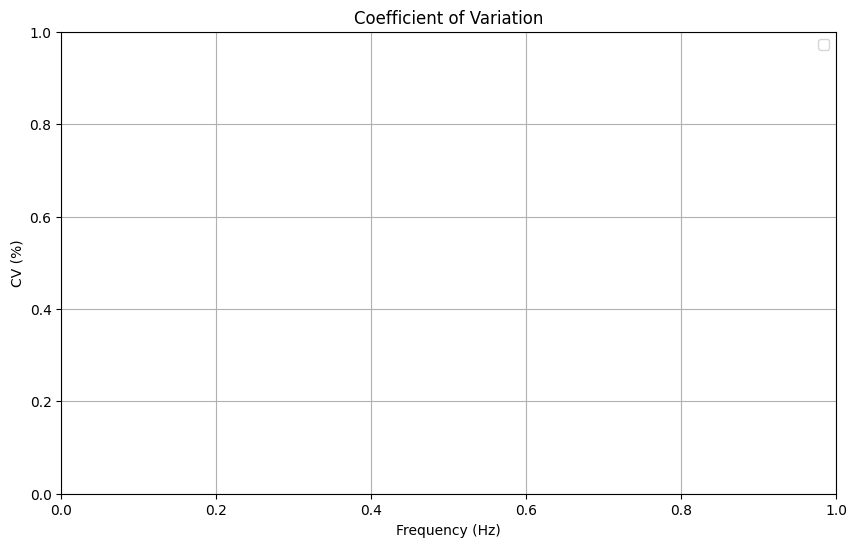

In [9]:
plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():
    cv = (
                 data["std"]
                 / data["mean"]
         ) * 100

    plt.plot(
        data["frequency"],
        cv,
        linewidth=2,
        label=group_name
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("CV (%)")
plt.title("Coefficient of Variation")
plt.legend()
plt.grid()

plt.savefig("03_cv.png", dpi=300)
plt.show()

|Correlation Matrix

In [10]:
corr_df = pd.DataFrame()

for group_name, data in group_data.items():
    corr_df[group_name] = data["mean"]

corr_df = pd.DataFrame({
    "0%": group_data["No fracture"]["mean"],
    "25%": group_data["25% Fracture"]["mean"],
    "50%": group_data["50% Fracture"]["mean"],
    "75%": group_data["75% Fracture"]["mean"],
    "100%": group_data["100% Fracture"]["mean"]
})

corr = corr_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Between Fracture Groups")

plt.savefig(
    "04_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

KeyError: 'No fracture'

Difference Relative To Healthy

In [ ]:
healthy = group_data["No fracture"]["mean"]

plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():

    if group_name == "No fracture":
        continue

    difference = (
                         data["mean"] - healthy
                 ) / healthy * 100

    plt.plot(
        data["frequency"],
        difference,
        linewidth=2,
        label=group_name
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Difference (%)")
plt.title("Percentage Difference Relative To Healthy")
plt.legend()
plt.grid()

plt.savefig(
    "05_percentage_difference.png",
    dpi=300
)

plt.show()

Best Frequency

In [ ]:
healthy = group_data["No fracture"]["mean"]

print("BEST DETECTION FREQUENCIES")
print("=" * 40)

for group_name, data in group_data.items():

    if group_name == "No fracture":
        continue

    diff = np.abs(
        (data["mean"] - healthy)
        / healthy
    )

    idx = np.argmax(diff)

    print(
        f"{group_name}: "
        f"{data['frequency'][idx]:.0f} Hz "
        f"({diff[idx] * 100:.2f}%)"
    )

P-Value Plot

In [ ]:
healthy_raw = group_data["No fracture"]["raw"]

plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():

    if group_name == "No fracture":
        continue

    p_values = []

    for i in range(len(data["frequency"])):
        _, p = ttest_ind(
            healthy_raw[:, i],
            data["raw"][:, i],
            equal_var=False
        )

        p_values.append(p)

    plt.plot(
        data["frequency"],
        p_values,
        label=group_name
    )

plt.axhline(
    0.05,
    linestyle="--",
    label="p = 0.05"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("p-value")
plt.title("Statistical Significance")
plt.legend()
plt.grid()

plt.savefig(
    "06_pvalues.png",
    dpi=300
)

plt.show()

PCA

In [ ]:
X = []
y = []

for group_name, data in group_data.items():

    for sweep in data["raw"]:

        # Remove 10–20 kHz region
        filtered_sweep = sweep[3:]

        X.append(filtered_sweep)
        y.append(group_name)

X = np.array(X)

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))

for group_name in np.unique(y):

    mask = np.array(y) == group_name

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=80,
        label=group_name
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA of Impedance Spectra (20–100 kHz)")
plt.legend()
plt.grid()

plt.savefig(
    "07_pca_no_10_20khz.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from scipy.spatial.distance import euclidean

healthy = group_data["No fracture"]["mean"]

for group, data in group_data.items():

    if group == "No fracture":
        continue

    dist = euclidean(
        healthy,
        data["mean"]
    )

    print(group, dist)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():

    plt.plot(
        data["frequency"],
        data["mean"],
        label=group_name
    )

    plt.fill_between(
        data["frequency"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2
    )


plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance (Ohms)")
plt.title("Average Impedance Spectrum")
plt.legend()
plt.grid(True)

plt.savefig("average_impedance.png", dpi=300)
plt.show()

Phase angle

In [ ]:
plt.figure(figsize=(10, 6))

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    phases = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        phase = np.degrees(
            np.arctan2(
                df["imaginary"].values,
                df["real"].values
            )
        )

        phases.append(phase)

    phases = np.vstack(phases)

    mean_phase = np.mean(phases, axis=0)
    std_phase = np.std(phases, axis=0)

    plt.plot(
        frequency,
        mean_phase,
        marker='o',
        label=f"{label} (n={len(phases)})"
    )

    plt.fill_between(
        frequency,
        mean_phase - std_phase,
        mean_phase + std_phase,
        alpha=0.2
    )

    print(f"{label}: Mean phase angle at 100 kHz = {mean_phase[-1]:.2f}° ± {std_phase[-1]:.2f}°")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Angle (°)")
plt.title("Average Phase Spectrum")
plt.grid(True)
plt.legend()

plt.savefig(
    "skin_phase_angle_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Euclidean distance between mean phase spectra

In [ ]:
from scipy.spatial.distance import pdist, squareform
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create matrix of mean spectra
group_names = list(group_data.keys())

mean_spectra = np.array([
    group_data[group]["mean"]
    for group in group_names
])

# Calculate Euclidean distances
distance_matrix = squareform(
    pdist(mean_spectra, metric="euclidean")
)

# Put into DataFrame
distance_df = pd.DataFrame(
    distance_matrix,
    index=group_names,
    columns=group_names
)

print(distance_df)

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    distance_df,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

plt.title("Euclidean Distance Between Fracture Groups")
plt.tight_layout()

plt.savefig(
    "08_euclidean_distance_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()